In [2]:
print("gello")

gello


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["default"] #"Bacterial infection", # A changer pour bacterial !!! 
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score",
                  "Neutrophils","Temp","SpO2","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no","Charlson_index"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SpO2 → NaN remplacés par la médiane (92.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'DG1' absente du DataFrame, ignorée.
⚠️ Colonne 'DG2' absente du DataFrame, ignorée.
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [4]:
df["GvHD"].value_counts()

GvHD
0    382
2    157
3    118
4     80
1     35
       8
Name: count, dtype: int64

(array([3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00,
        4.000e+00, 9.000e+00, 2.300e+01, 6.318e+03]),
 array([0.        , 0.09722202, 0.19444405, 0.29166607, 0.38888809,
        0.48611012, 0.58333214, 0.68055416, 0.77777619, 0.87499821,
        0.97222023]),
 <BarContainer object of 10 artists>)

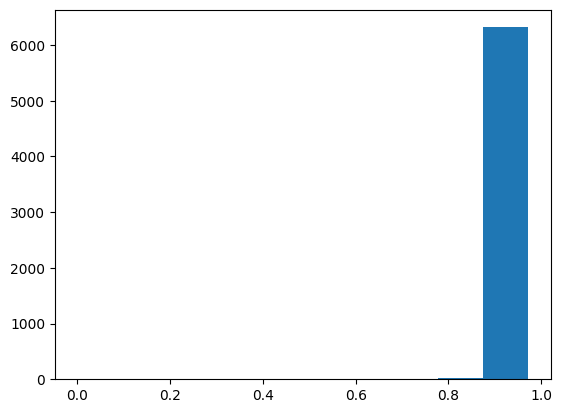

In [5]:
plt.hist(df_features_clean['SaO2'])


In [6]:
import sys
sys.modules.pop('utils.feature_importance', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)
sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.visualisation', None)
sys.modules.pop('utils.data_aug', None)
sys.modules.pop('utils.models_and_metrics', None) 
sys.modules.pop('utils.run_model', None) 


In [7]:
L = df_features_clean.columns
print(L)
print("Alveolar_cons_Focal" in L)

Index(['Sex', 'Time H-ICU', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU', 'GvHD',
       'Sys_dis', 'Solid_tumor', 'Organ_transpl', 'Chemotherapy',
       'Ibr_Flu_Met', 'Immuno_drugs', 'Tar_ther', 'Immunotherapy',
       'Carttcells', 'Steroids_YN', 'Charlson_index', 'Prophylaxis_antifungal',
       'Prophylaxis_bacterial', 'Prophylaxis_viral', 'Vaccins#Flu',
       'Vaccins#COVID', 'Vaccins#Other', 'SOFA_Nervous', 'Hemoptysis',
       'PaO2/FiO2 VALUE VALUE', 'Pleural_eff', 'Quad_no', 'Excavation',
       'Septal_line', 'Halo_sign', 'Lymph_bulky', 'Age_scaled', 'Hem_mal_AML',
       'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma',
       'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS',
       'Hem_mal_other', 'Disease_status_inaugural', 'Disease_status_remission',
       'Disease_status_evolutive', 'HSCT_BMT_Autograft', 'HSCT_BMT_Allograft',
       'Nodules_any', 'GGO', 'SOFA_scaled', 'SaO2', 'Resp_severity',
       'Temp_gravité', 'Leukostase', 'Neut

In [8]:
L = df_cat_clean.columns
print(L)

Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Pneumocystis jirovecii infection',
       'Mucorales', 'Other fungal ', 'Other infection ',
       'Cardiogenic pulmonary oedema', 'Drug toxicity related',
       'Disease-related infiltrates', 'Transfusion-related acute lung injury',
       'Other non infectious causes'],
      dtype='object')


In [8]:

df__with_diag = pd.concat([df_features_clean,df_cat_clean],axis=1)

enlever_clinic = lambda X: ((X["Pneumonia_clinic"] == 1) & (X["Pneumonia_microbio"] == 0) & (X["Bacterial infection"] == 1))
mask = enlever_clinic(df__with_diag)
df_features_clean = df_features_clean[~mask]
df_cat_clean = df_cat_clean[~mask]
df_features_clean  = df_features_clean.drop(columns =["Pneumonia_clinic", "Pneumonia_microbio"])

df_features_clean.columns

KeyError: 'Pneumonia_clinic'

# Mapping classes

In [9]:
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other infection' : ['Other infection '],
                    'Other non infectious causes': ['Other non infectious causes','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels

df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")
print((df_labels_fusion.sum(axis=0))/len(df_labels_fusion))
print(df_labels_fusion.columns)


Bacterial infection                 0.435692
Viral infection                     0.288836
Invasive pulmonary aspergillosis    0.051572
All fungus                          0.053774
Other fungal                        0.041509
Mucorales                           0.013836
Pneumocystis jirovecii infection    0.052358
Cardiogenic pulmonary oedema        0.132233
Disease-related infiltrates         0.121698
Drug toxicity related               0.041509
Other infection                     0.037107
Other non infectious causes         0.314151
dtype: float64
Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'All fungus', 'Other fungal',
       'Mucorales', 'Pneumocystis jirovecii infection',
       'Cardiogenic pulmonary oedema', 'Disease-related infiltrates',
       'Drug toxicity related', 'Other infection',
       'Other non infectious causes'],
      dtype='object')


# Model 1 classe

In [10]:
import os 
target_col =  'Bacterial infection'
os.path.exists(r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\" ) 

True

==== Pneumocystis jirovecii infection ====
Monte Carlo 1/5 (seed=42)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/5 (seed=43)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/5 (seed=44)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/5 (seed=45)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/5 (seed=46)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Meilleur combo -> Modele: Random Forest | Augmentation: SMOTEENN | roc_auc (moyenne MC): 0.7139 | std: 0.0105 | meill

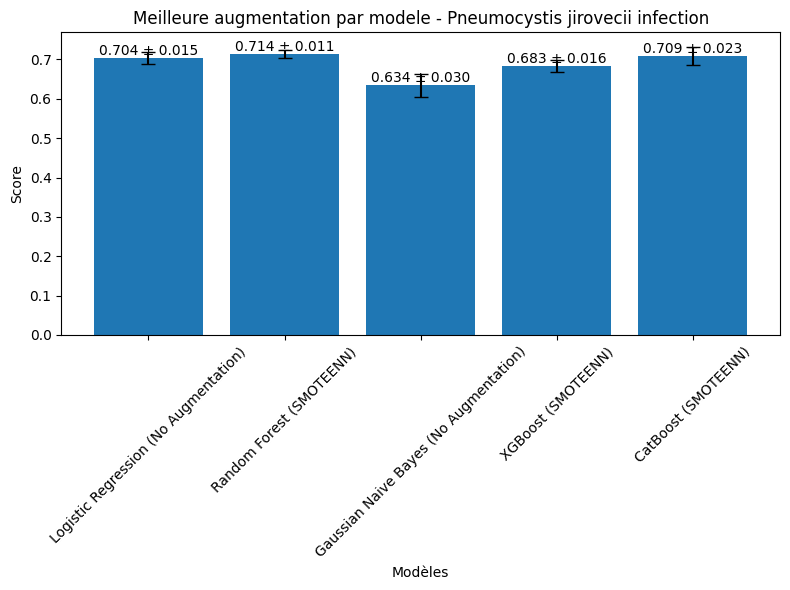


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (No Augmentation) â€” roc_auc moyen = 0.7045 Â± 0.0150 | seuil Youden = 0.4960
- Random Forest (SMOTEENN) â€” roc_auc moyen = 0.7139 Â± 0.0105 | seuil Youden = 0.2267
- Gaussian Naive Bayes (No Augmentation) â€” roc_auc moyen = 0.6341 Â± 0.0297 | seuil Youden = 0.1787
- XGBoost (SMOTEENN) â€” roc_auc moyen = 0.6834 Â± 0.0163 | seuil Youden = 0.0374
- CatBoost (SMOTEENN) â€” roc_auc moyen = 0.7094 Â± 0.0230 | seuil Youden = 0.0959


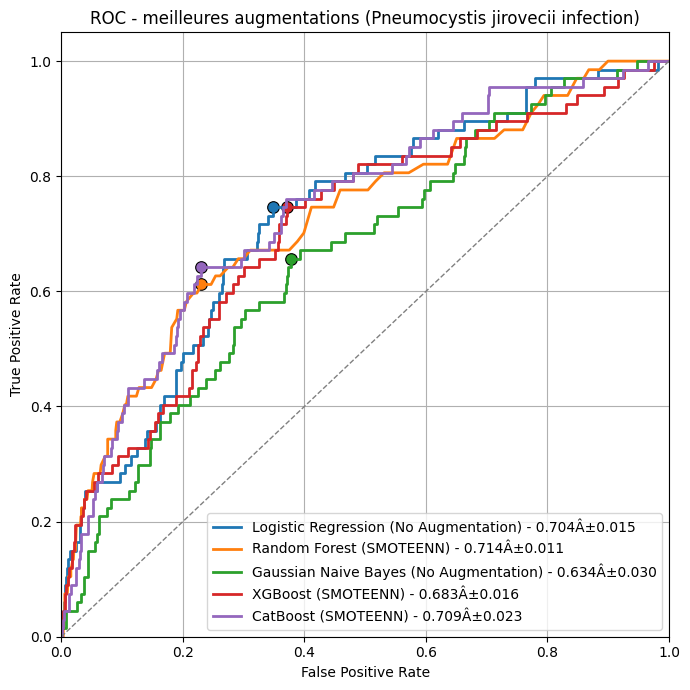

Configuration sauvegard?e dans config_Pneumocystis jirovecii infection.yaml


In [15]:
from utils.run_model import find_best_model_and_aug
RANDOM_SEED = 42
target_col =  'Pneumocystis jirovecii infection'
# os.mkdir(r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\" + target_col + "\\")
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'Gaussian Naive Bayes', 'XGBoost',"CatBoost"]
# MODEL_NAMES =  ['Random Forest']
save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search"
MAIN_METRIC_NAME = 'roc_auc'
_ = find_best_model_and_aug(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   write_config = True,
                   random_seed=RANDOM_SEED,
                   to_save = True,
                   save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\")


In [ ]:
df_labels_fusion.columns
# big loop 
RANDOM_SEED = 42
L_labels = [
       'Invasive pulmonary aspergillosis', 'Other fungal', 'Mucorales',
       'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
       'Disease-related infiltrates', 'Drug toxicity related',
       'Other non infectious causes']
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'Gaussian Naive Bayes', 'XGBoost',"CatBoost"]
for target_col in df_labels_fusion.columns:

    #MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost']
    # MODEL_NAMES =  ['Random Forest']
    MAIN_METRIC_NAME = 'roc_auc'
    _ = find_best_model_and_aug(df_features_clean, 
                    df_labels_fusion, 
                    target_col,
                    MODEL_NAMES,
                    MAIN_METRIC_NAME,
                    write_config = True,
                    random_seed=RANDOM_SEED,
                    montecarlo = 10,
                    to_save = True,
                    save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\")

# Run of config

In [2]:
!pip

'c:\Users\romai\Desktop\codes\respiratory_diagnostics\.venv\Scripts\pip.exe' a �t� bloqu� par la strat�gie Device Guard de votre organisation.
Pour plus d'informations, contactez la personne charg�e du support. 



📊 Répartition des classes : pos=0.051, neg=0.949
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Invasive pulmonary aspergillosis.yaml
Modèle = Random Forest | Augmentation = BorderlineSMOTE | Métrique = roc_auc
----- run_model_aug -----
target_col=Invasive pulmonary aspergillosis
model=Random Forest
augmentation=BorderlineSMOTE
metric=roc_auc | threshold=0.10666666666666667
show_roc=True, show_importance=True, show_shap=False
sensibilite=False, type_sensi=all
features_sensibilite=['Neutropenie', 'Prophylaxis_antifungal']
Random Forest | BorderlineSMOTE -> roc_auc: 0.7028
Negative Predictive Value: 0.9651416122004357


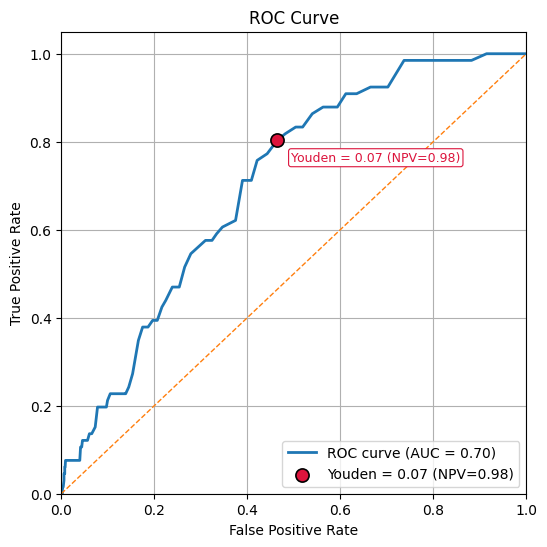

ROC AUC = 0.70
Negative Predictive Value youden: 0.9781659388646288 threshold  0.07


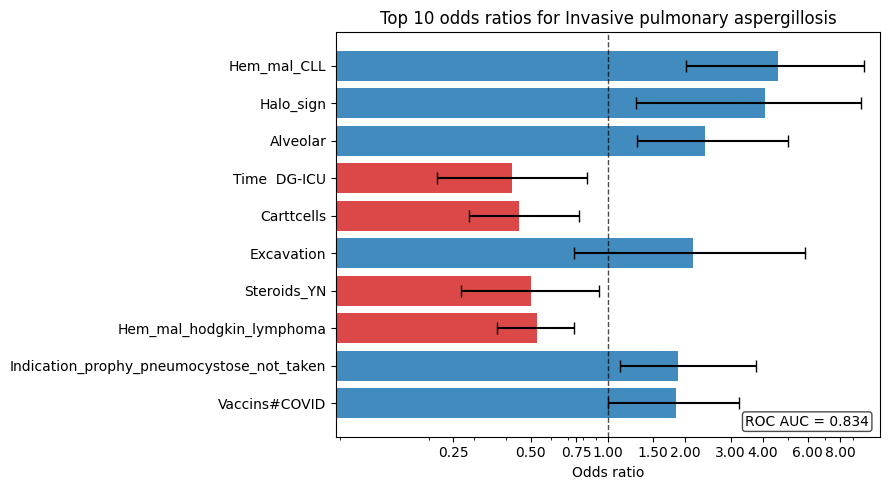

Impossible de calculer at_least_one_correct : axis 1 is out of bounds for array of dimension 1
Impossible de calculer reject_n_lowest_correct : invalid index to scalar variable.


In [28]:
sys.modules.pop('utils.run_model',None)
sys.modules.pop('utils.visualisation',None)
sys.modules.pop('utils.feature_importance',None)
from utils.run_model import run_config_for_target
import os 
config_dir = os.getcwd() + '\\configs\\'
target_col = 'Invasive pulmonary aspergillosis'
features_hemato =['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']

# cols = [ 'Other fungal', 'Mucorales',
#        'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
#        'Disease-related infiltrates', 'Drug toxicity related',
#        'Other non infectious causes']
features_sensibilite = ["Neutropenie", "Prophylaxis_antifungal"]
#for target_col in df_labels_fusion.columns:
condition = lambda X: (X[features_hemato] > 0).any(axis=1)
# condition = lambda X: (X[features_hemato] == 0).all(axis=1)

run_output = run_config_for_target(target_col,
                     df_features_clean,
                     df_labels_fusion,
                     sensibilite = False,
                     show_importance = True,
                     show_roc = True,
                     show_shap = False,
                     features_sensibilite = features_sensibilite,
                     type_sensi = 'all',
                     method_importance = 'native_importance',
                     config_dir = config_dir,
                     condition_test=None,
                       to_save = False,
                     save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\")

In [12]:
run_output['metric_scores']

{'accuracy': 0.7421383647798742,
 'precision': 0.09567901234567901,
 'recall': 0.4696969696969697,
 'f1': 0.15897435897435896,
 'f_beta': 0.15897435897435896,
 'negative_predictive_value': 0.9630801687763713,
 'lr_positive': 1.933291964008688,
 'lr_negative': 0.7004879020213083,
 'roc_auc': 0.7208528066737022,
 'pr_auc': 0.12024738905476567,
 'logloss': 0.19520704010506285,
 'brier': 0.04952682564640112}

In [11]:
sys.modules.pop('utils.run_model',None)
from utils.analyse_sensibilite import analyse_sensibilite

from utils.run_model import run_model_aug
run_model_aug

<function utils.run_model.run_model_aug(model_name, base_model, augmentation_name, augmentation, X_train, X_test, y_train, y_test, MAIN_METRIC_NAME, metric_fn, needs_proba, THRESHOLD, target_col, feature_names, show_roc=False, show_importance=False, show_shap=False, method_importance='native_importance', sensibilite=False, features_sensibilite=['Neutropenie', 'Prophylaxis_antifungal'], type_sensi='all', verbose=False, text_save=None, to_save=False, save_dir=None)>


📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Pneumocystis jirovecii infection.yaml
Modèle = Random Forest | Augmentation = No Augmentation | Métrique = roc_auc
----- run_model_aug -----
target_col=Pneumocystis jirovecii infection
model=Random Forest
augmentation=No Augmentation
metric=roc_auc | threshold=0.05333333333333334
show_roc=False, show_importance=False, show_shap=False
sensibilite=True, type_sensi=all
features_sensibilite=Neutropenie
Random Forest | No Augmentation -> roc_auc: 0.7150
Negative Predictive Value: 0.9688249400479616
C:\Users\romai\Desktop\travail\avancement\model_grid_search\\Pneumocystis_jirovecii_infection\Neutropenie\\


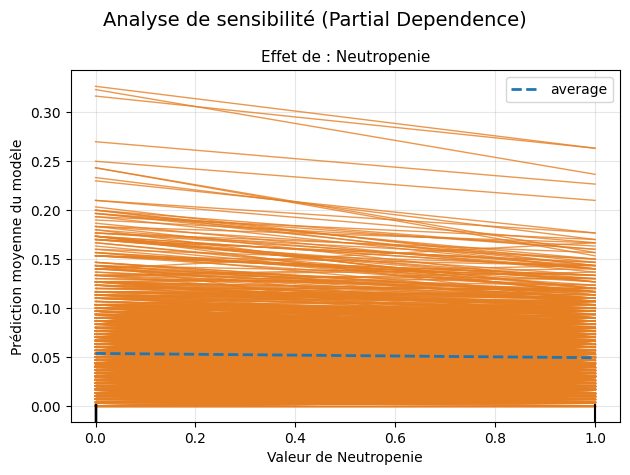

Impossible de calculer at_least_one_correct : axis 1 is out of bounds for array of dimension 1
Impossible de calculer reject_n_lowest_correct : invalid index to scalar variable.

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Pneumocystis jirovecii infection.yaml
Modèle = Random Forest | Augmentation = No Augmentation | Métrique = roc_auc
----- run_model_aug -----
target_col=Pneumocystis jirovecii infection
model=Random Forest
augmentation=No Augmentation
metric=roc_auc | threshold=0.05333333333333334
show_roc=False, show_importance=False, show_shap=False
sensibilite=True, type_sensi=all
features_sensibilite=['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']
Random Forest | No Augm

c:\Users\romai\Desktop\codes\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


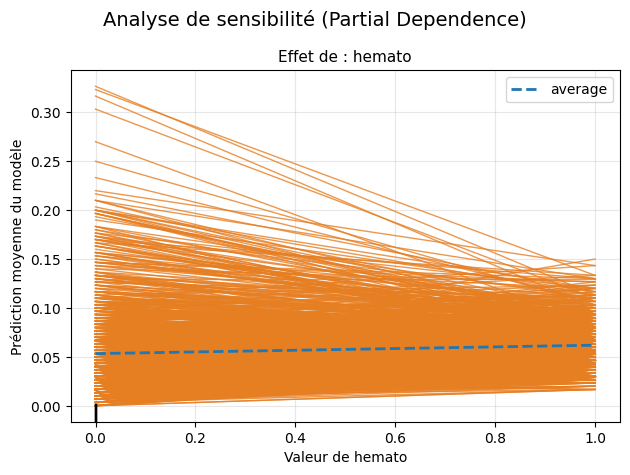

Impossible de calculer at_least_one_correct : axis 1 is out of bounds for array of dimension 1
Impossible de calculer reject_n_lowest_correct : invalid index to scalar variable.


In [ ]:
import os 
config_dir = os.getcwd() + '\\configs\\'
target_col = 'Pneumocystis jirovecii infection'
from utils.run_model import run_config_for_target

def _slugify(value):
        clean = "".join(char if char.isalnum() else "_" for char in (value or ""))
        clean = clean.strip("_")
        return clean or "target"
RANDOM_SEED = 42

MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'Gaussian Naive Bayes', 'XGBoost',"CatBoost"]
MAIN_METRIC_NAME = 'roc_auc'
save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\"
def run_all_for_column(target_col,
                     to_save = False,
                     save_dir = save_dir):
        
        # 1 
        # _ = find_best_model_and_aug(df_features_clean, 
        #             df_labels_fusion, 
        #             target_col,
        #             MODEL_NAMES,
        #             MAIN_METRIC_NAME,
        #             write_config = True,
        #             random_seed=RANDOM_SEED,
        #             montecarlo = 10,
        #             to_save = True,
        #             save_dir = save_dir)
        def run_3_4(condition_test,
                        save_dir,
                        text_save = None):
                run_output = run_config_for_target(target_col,
                                df_features_clean,
                                df_labels_fusion,
                                show_importance = False,
                                show_roc = True,
                                show_shap = False,
                                method_importance = 'native_importance',
                                config_dir = config_dir,
                                condition_test=condition_test ,
                                to_save = to_save,
                                save_dir = save_dir,
                                text_save = text_save,)
                if to_save:
                        metrics_score = run_output['metric_scores']
                        if text_save is not None:
                                best_summary_path = save_dir + _slugify(target_col) + text_save + "metrics.json"

                        else:
                                best_summary_path = save_dir + _slugify(target_col)  + "metrics.json"
                        
                        best_summary_path = Path(best_summary_path)

                        with best_summary_path.open("w", encoding="utf-8") as handle:
                                json.dump(metrics_score, handle, indent=2)
        # 2 
        run_config_for_target(target_col,
                                df_features_clean,
                                df_labels_fusion,
                                show_importance = True,
                                show_roc = False,
                                show_shap = False,
                                method_importance = 'native_importance',
                                config_dir = config_dir,
                                condition_test=None ,
                                to_save = to_save,
                                save_dir = save_dir)
        # 3 et 4 
        run_3_4(condition_test=None,save_dir=save_dir)
        # Analyse de sensibilite (5)
        
        condition_neutropenie =  lambda X: (X["Neutropenie"] == 1)

        run_3_4(condition_test=condition_neutropenie,save_dir=save_dir,text_save =r"\Neutropenie\\" )
        features_hemato =['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']

        condition_hemato = lambda X: (X[features_hemato] > 0).any(axis=1)
        
        run_3_4(condition_test=condition_hemato,save_dir=save_dir,text_save =r"\Hemato\\")

        # PDP 
        run_config_for_target(target_col,
                                df_features_clean,
                                df_labels_fusion,
                                show_importance = False,
                                show_roc = False,
                                show_shap = False,
                                method_importance = 'native_importance',
                                config_dir = config_dir,
                                features_sensibilite ="Neutropenie",
                                type_sensi = 'all',
                                sensibilite=True,           
                                condition_test=None ,
                                to_save = to_save,
                                save_dir = save_dir,
                                text_save = r"\Neutropenie\\",)
        run_config_for_target(target_col,
                                df_features_clean,
                                df_labels_fusion,
                                show_importance = False,
                                show_roc = False,
                                show_shap = False,
                                method_importance = 'native_importance',
                                config_dir = config_dir,
                                features_sensibilite =features_hemato,
                                type_sensi = 'all',
                                sensibilite=True,           
                                condition_test=None ,
                                to_save = to_save,
                                save_dir = save_dir,
                                text_save =r"\Hemato\\")
run_all_for_column(target_col,
                    to_save = True,
                    save_dir = save_dir)


📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Pneumocystis jirovecii infection.yaml
Modèle = CatBoost | Augmentation = SMOTEENN | Métrique = roc_auc
----- run_model_aug -----
target_col=Pneumocystis jirovecii infection
model=CatBoost
augmentation=SMOTEENN
metric=roc_auc | threshold=0.08756228675704687
show_roc=False, show_importance=False, show_shap=False
sensibilite=True, type_sensi=all
features_sensibilite=['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']
CatBoost | SMOTEENN -> roc_auc: 0.7019
Negative Predictive Value: 0.967982924226254


c:\Users\romai\Desktop\codes\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


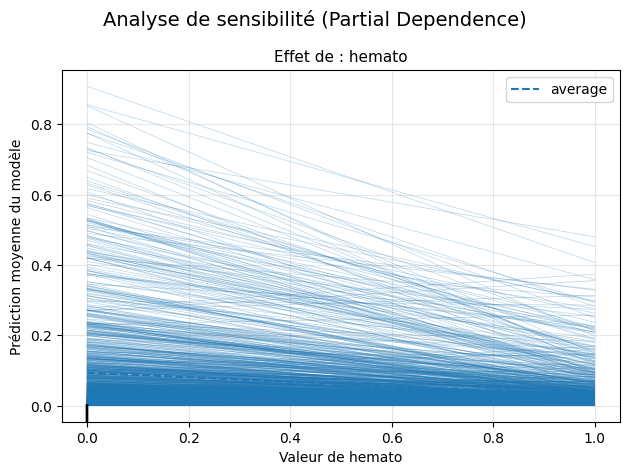

Impossible de calculer at_least_one_correct : axis 1 is out of bounds for array of dimension 1
Impossible de calculer reject_n_lowest_correct : invalid index to scalar variable.


{'score': 0.7018517371647984,
 'pipe_train': Pipeline(steps=[('scaler',
                  AutoStandardScaler(colonnes_numeriques=['Sex', 'Time H-ICU',
                                                          'TIME SYMPTOMES-ICU',
                                                          'Time  DG-ICU',
                                                          'Sys_dis',
                                                          'Solid_tumor',
                                                          'Organ_transpl',
                                                          'Drug_induced',
                                                          'Chemotherapy',
                                                          'Ibr_Flu_Met',
                                                          'Immuno_drugs',
                                                          'Tar_ther',
                                                          'Immunotherapy',
                                      

In [10]:

features_hemato =['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']
target_col = 'Pneumocystis jirovecii infection'

import os 
config_dir = os.getcwd() + '\\configs\\'
run_config_for_target(target_col,
                        df_features_clean,
                        df_labels_fusion,
                        show_importance = False,
                        show_roc = False,
                        show_shap = False,
                        method_importance = 'native_importance',
                        config_dir = config_dir,
                        features_sensibilite =features_hemato,
                        type_sensi = 'all',
                        sensibilite=True,           
                        condition_test=None ,
                        to_save = False)

In [11]:
df_features_clean['GGO'].value_counts()

GGO
1.0    4180
0.0    2180
Name: count, dtype: int64

# Log reg

In [13]:
sys.modules.pop('utils.log_reg',None)
from utils.log_reg import run_univariate_log_reg 
metrics = get_metric()
MAIN_METRIC_NAME = 'roc_auc'
target_col = 'Pneumocystis jirovecii infection'
metric_entry = metrics[MAIN_METRIC_NAME]
metric_fn = metric_entry["metric_fn"]
run_univariate_log_reg(df_features_clean, df_labels_fusion, target_col, metric_fn=metric_fn,top_k=5)


Top 5 variables explicatives (metric = roc_auc)
     feature  roc_auc  coefficient  intercept
     Quad_no 0.636484     0.335164  -3.879700
         GGO 0.636131     0.943548  -3.582655
 Steroids_YN 0.617595     0.612270  -3.162290
 Pleural_eff 0.616282    -0.375005  -2.725392
Drug_induced 0.605599     0.297549  -2.989080


,feature,roc_auc,coefficient,intercept
0,Quad_no,0.636484,0.335164,-3.879700
1,GGO,0.636131,0.943548,-3.582655
2,Steroids_YN,0.617595,0.612270,-3.162290
3,Pleural_eff,0.616282,-0.375005,-2.725392
4,Drug_induced,0.605599,0.297549,-2.989080


# Save / load fichiers

In [ ]:
from utils.model_saving import save_model, load_model
from utils.run_model import run_config_for_target

import os 
config_dir = os.getcwd() + '\\configs\\'

target_col = 'Pneumocystis jirovecii infection'
# for target_col in df_labels_fusion:
print(target_col)
run_output = run_config_for_target(target_col,
                    df_features_clean,
                    df_labels_fusion,
                    sensibilite = False,
                    show_importance = False,
                    show_roc = False,
                    show_shap = False,
                    features_sensibilite = None,
                    type_sensi = 'all',
                    method_importance = 'native_importance',
                    config_dir = config_dir,
                    condition_test=None,
                      to_save = False,
                    save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\")
# Après run_config_for_target / run_model_aug
save_model(
    diagnostic=target_col,
    pipe_train=run_output["pipe_train"],
    pipe_inference=run_output["pipe_inference"],
    youden_threshold=run_output["Youden_threshold"],
    model_dir = os.getcwd() + r'\models\\',
    metadata={},
    overwrite= True
)

loaded = load_model(diagnostic =target_col,
                  model_dir = os.getcwd() + r'\models\\'
                  )
pipe_inference = loaded["pipe_inference"]
# proba_raw = pipe_inference.predict_proba(X_test)
print(pipe_inference)

Pneumocystis jirovecii infection

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Pneumocystis jirovecii infection.yaml
Modèle = Random Forest | Augmentation = SMOTEENN | Métrique = roc_auc
----- run_model_aug -----
target_col=Pneumocystis jirovecii infection
model=Random Forest
augmentation=SMOTEENN
metric=roc_auc | threshold=0.22666666666666666
show_roc=False, show_importance=False, show_shap=False
sensibilite=False, type_sensi=all
features_sensibilite=['Neutropenie', 'Prophylaxis_antifungal']
Random Forest | SMOTEENN -> roc_auc: 0.7184
Negative Predictive Value: 0.9680851063829787
Pipeline(steps=[('scaler',
                 AutoStandardScaler(colonnes_numeriques=['Sex', 'Time H-ICU',
                                                         'TIME SYMPTOMES-ICU',
                                     

: 

In [13]:
loaded.keys()

dict_keys(['diagnostic', 'saved_at', 'pipe_train', 'pipe_inference', 'metadata', 'Youden_threshold'])

In [14]:
df_features_clean.columns

Index(['Sex', 'Time H-ICU', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU', 'GvHD',
       'Sys_dis', 'Solid_tumor', 'Organ_transpl', 'Chemotherapy',
       'Ibr_Flu_Met', 'Immuno_drugs', 'Tar_ther', 'Immunotherapy',
       'Carttcells', 'Steroids_YN', 'Charlson_index', 'Prophylaxis_antifungal',
       'Prophylaxis_bacterial', 'Prophylaxis_viral', 'Vaccins#Flu',
       'Vaccins#COVID', 'Vaccins#Other', 'SOFA_Nervous', 'Hemoptysis',
       'PaO2/FiO2 VALUE VALUE', 'Pleural_eff', 'Quad_no', 'Excavation',
       'Septal_line', 'Halo_sign', 'Lymph_bulky', 'Age_scaled', 'Hem_mal_AML',
       'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma',
       'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS',
       'Hem_mal_other', 'Disease_status_inaugural', 'Disease_status_remission',
       'Disease_status_evolutive', 'HSCT_BMT_Autograft', 'HSCT_BMT_Allograft',
       'Nodules_any', 'GGO', 'SOFA_scaled', 'SaO2', 'Resp_severity',
       'Temp_gravité', 'Leukostase', 'Neut

In [13]:
run_output['pipe_inference']

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,colonnes_numeriques,"['Sex', 'Time H-ICU', ...]"


In [44]:
save_model(
    diagnostic='Bacterial infection',
    pipe_train=run_output["pipe_train"],
    pipe_inference=run_output["pipe_inference"],
    model_dir = os.getcwd() + r'\models\\',
    metadata={},
    overwrite= True
)

PicklingError: Can't pickle <class 'utils.algo_prediction.AutoStandardScaler'>: it's not the same object as utils.algo_prediction.AutoStandardScaler

In [33]:
print(type(pipe_inference))

<class 'imblearn.pipeline.Pipeline'>


In [51]:
import huggingface_hub
huggingface_hub.login()

# Multioutput

In [2]:
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve
from utils.models_and_metrics import negative_predictive_value
from sklearn.metrics import (roc_auc_score)
from utils.visualisation import multilabel_roc
import numpy as np
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_fusion) 

models = get_models(y_train,multilabel=True,imbalance_threshold=0.01,use_catboost=False)
augmentations = get_augmentation_methods(random_state=0)
print(augmentations.keys())

metrics = get_metric()
print(metrics.keys())

results = []
metrique = f1_metric_xgb
for model_name, model in models.items():
    print("Model:", model_name)
    
    pipe_train = Pipeline([
        ("scaler", AutoStandardScaler()),
        # ("augmentation", augmentations['SMOTE']),
        ("model",model )
    ])
    # Changement de la métrique plus tard
    # pipe_train.set_params(model__eval_metric=f1_metric_xgb)


    pipe_train.fit(X_train, y_train)

    metric_fn=metrics['roc_auc']["metric_fn"]
    needs_proba=metrics['roc_auc']["needs_proba"]


    pipe_test = Pipeline([
        ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
        ("model", pipe_train.named_steps["model"])     # modèle déjà fit
    ])

    if needs_proba:
        y_pred = pipe_test.predict_proba(X_test)
    else:
        y_pred = pipe_test.predict(X_test)
    probas_array = np.column_stack([p[:, 1] for p in y_pred])

    a = multilabel_roc(
        np.array(y_test), probas_array,
        plot=True,
        label_names=y_test.columns.to_list(),
        per_label_max=8,   # ne tracer que les 8 meilleures courbes par label
        show_micro=True,
        show_macro=True
        )

    # score = roc_auc_score(y_test, y_pred, average="macro")
    # show_metrics_binary(y_test, y_pred)
    # show_roc_curve(y_test, y_pred)
    # print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))

NameError: name 'df_features_clean' is not defined

In [ ]:
from utils.models_and_metrics import get_models_multilabel, compare_models_metric, get_metric
from sklearn.metrics import hamming_loss
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
# Charger les mod?les multilabel sp?cialis?s
models = get_models_multilabel()

metrics = get_metric()
# print(metrics['f1']'metric_fn')
# Pr?parer les donn?es
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_fusion)

# Comparer avec une m?trique multilabel
df_scores = compare_models_metric(
    models,
    metric_fn=f1_score,  # ou f1_score avec un autre average
    metric_kwargs={"average": "weighted"},
    metric_name="f1_weighted",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    needs_proba=False
)

print(df_scores)


# SHAP values

In [ ]:
sys.modules.pop('utils.feature_importance', None)
from utils.feature_importance import shap_top10_per_estimator,plot_top10_features_per_estimator
plot_top10_features_per_estimator(modele,feature_names=X_train.columns,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/importance')
shap_top10_per_estimator(model= modele,X = X_test_sc,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/shap')

In [ ]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple #+ features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)




In [ ]:
df_col_utils.isna().any().any()
# print(df_features_clean.isna().sum()[df_features_clean.isna().sum() > 0])


In [ ]:
L_radio = ['Alveolar_xray_No', 'Alveolar_xray_Focal',
       'Alveolar_xray_Diffuse', 'Interst_xray_No', 'Interst_xray_Focal',
       'Interst_xray_Diffuse', 'Alveolar_cons_No', 'Alveolar_cons_Focal',
       'Alveolar_cons_Diffuse', 'Ground_glass_op_No', 'Ground_glass_op_Focal',
       'Ground_glass_op_Diffuse', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'SOFA_scaled', 'Sa02', 'Resp_severity',
       'Temp_gravité', 'Neutropenie']
for x in L_radio:
    print(df_features_clean[x].value_counts())

In [ ]:
df_features_clean.iloc[0]

In [ ]:
Implémenter from sklearn.model_selection import StratifiedKFold
